<a href="https://colab.research.google.com/github/AdityaInTech/Task-Modules/blob/main/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1: Imports for Week 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn tools and models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.datasets import fetch_california_housing

**Mini Project 2 - House Price Prediction Model**

Loading Housing Data from Colab's sample_data folder...
Training Linear Regression Model...
R-squared Score: 0.6636
Mean Squared Error (MSE): 4634658406.2233


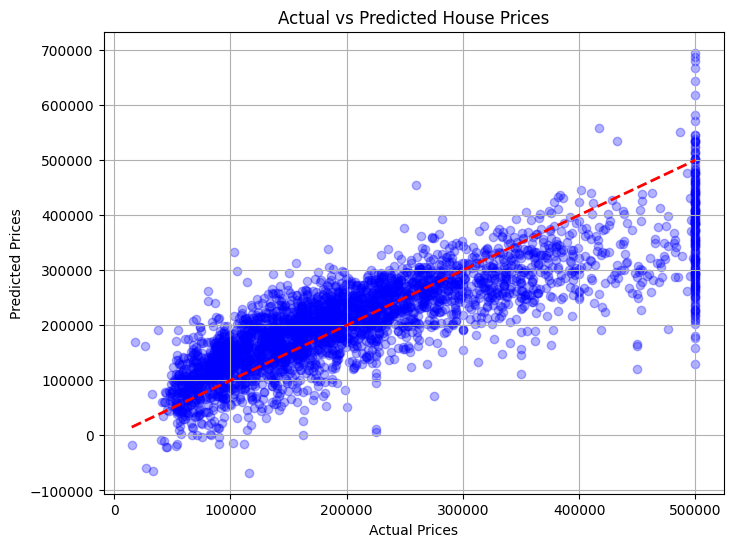

In [5]:
# Cell 2: House Price Prediction Model (Fixed for HTTP Error)

# 1. Load the housing dataset directly from Colab's pre-installed sample data
print("Loading Housing Data from Colab's sample_data folder...")
house_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# The target column in this specific CSV is named 'median_house_value'
X_house = house_df.drop('median_house_value', axis=1) # Features
y_house = house_df['median_house_value']              # Target (Prices)

# 2. Train/Test Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

# 3. Train Linear Regression model
print("Training Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train_h, y_train_h)

# 4. Predict house prices
y_pred_h = lr_model.predict(X_test_h)

# 5. Evaluate R2 score and MSE
r2 = r2_score(y_test_h, y_pred_h)
mse = mean_squared_error(y_test_h, y_pred_h)
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# 6. Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.3, color='blue')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

**Assignment & Practice - Logistic Regression on Titanic**

Training Logistic Regression Model...
Logistic Regression Accuracy: 81.01%

Confusion Matrix:
[[90 15]
 [19 55]]


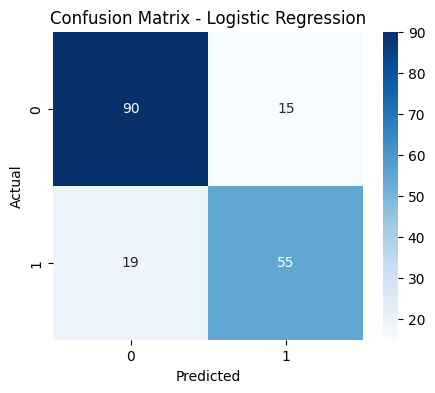

In [4]:
# Cell 3: Titanic Survival Prediction using Logistic Regression

# Quick reload and clean of Titanic data (so this cell works independently)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url)
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 1, 'female': 0})
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)

# Select features (X) and target (y)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
X_titanic = titanic_df[features]
y_titanic = titanic_df['Survived']

# Train/Test Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

# 1. Train Logistic Regression Model
print("Training Logistic Regression Model...")
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_t, y_train_t)

# 2. Predict and Evaluate
y_pred_log = log_reg.predict(X_test_t)
log_accuracy = accuracy_score(y_test_t, y_pred_log)
conf_matrix = confusion_matrix(y_test_t, y_pred_log)

print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Practice - Compare Decision Tree and KNN**

In [6]:
# Cell 4: Compare Decision Tree and KNN

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_t, y_train_t)
y_pred_dt = dt_classifier.predict(X_test_t)
dt_accuracy = accuracy_score(y_test_t, y_pred_dt)

# Train KNN
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_t, y_train_t)
y_pred_knn = knn_classifier.predict(X_test_t)
knn_accuracy = accuracy_score(y_test_t, y_pred_knn)

print("--- Model Comparison ---")
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print(f"KNN Accuracy:           {knn_accuracy * 100:.2f}%")

--- Model Comparison ---
Decision Tree Accuracy: 78.77%
KNN Accuracy:           69.83%


**Practice - Tune max_depth of Decision Tree**

In [7]:
# Cell 5: Tuning max_depth of Decision Tree

# The previous Decision Tree had no max_depth limit (which often leads to overfitting)
# Now, let's restrict the depth to 3
dt_tuned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_tuned.fit(X_train_t, y_train_t)

y_pred_tuned = dt_tuned.predict(X_test_t)
tuned_accuracy = accuracy_score(y_test_t, y_pred_tuned)

print("--- Tuning Results ---")
print(f"Original Decision Tree Accuracy (no depth limit): {dt_accuracy * 100:.2f}%")
print(f"Tuned Decision Tree Accuracy (max_depth=3):       {tuned_accuracy * 100:.2f}%")

print("\nNote: Restricting max_depth usually improves accuracy on the test set because it prevents the model from memorizing (overfitting) the training data.")

--- Tuning Results ---
Original Decision Tree Accuracy (no depth limit): 78.77%
Tuned Decision Tree Accuracy (max_depth=3):       79.89%

Note: Restricting max_depth usually improves accuracy on the test set because it prevents the model from memorizing (overfitting) the training data.
